In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [4]:
data = pd.read_csv("C:\\Users\\SHRAVANI\\OneDrive\\Desktop\\INTERNSHIP MAJOR PROJECT 2\\Crop_recommendation\\Crop_recommendation.csv")
print(data)

        N   P   K  temperature   humidity        ph    rainfall   label
0      90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1      85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2      60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3      74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4      78  42  42    20.130175  81.604873  7.628473  262.717340    rice
...   ...  ..  ..          ...        ...       ...         ...     ...
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

[2200 rows x 8 columns]


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
data.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
data=data.drop_duplicates()
print(data.shape)

(2200, 8)


In [8]:
X = data.drop("label", axis=1)
y = data["label"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(),

    "Naive Bayes": GaussianNB()
}
accuracy_scores = {}

best_accuracy = 0
best_model = None
best_model_name = ""

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    accuracy_scores[name] = accuracy

    print(f"{name} Accuracy: {accuracy*100:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

Logistic Regression Accuracy: 96.36%
Decision Tree Accuracy: 98.64%
Random Forest Accuracy: 99.32%
KNN Accuracy: 95.68%
SVM Accuracy: 96.82%
Naive Bayes Accuracy: 99.55%


In [9]:
print("Best Model:",best_model_name)
print("Best Accuracy:",best_accuracy*100)

Best Model: Naive Bayes
Best Accuracy: 99.54545454545455


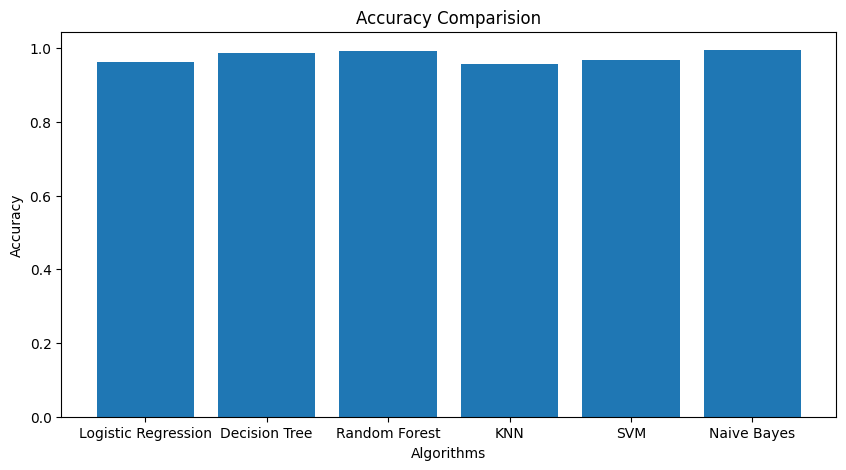

In [12]:
model_names=list(accuracy_scores.keys())
accuracies=list(accuracy_scores.values())
plt.figure(figsize=(10,5))
plt.bar(model_names,accuracies)
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparision")
plt.show()

In [14]:
joblib.dump(best_model,"best_model.pkl")
joblib.dump(scaler,"scaler.pkl")
print("Model and Scaler saved successfully")

Model and Scaler saved successfully
